#Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Install Packages and Libraries

In [ ]:
!pip install librosa


In [ ]:
import librosa
import numpy as np
import os
import matplotlib.pyplot as plt
import librosa.display

#Features extraction in AsvSpoof
#MFCC extraction

In [ ]:
# Base directory for ASVspoof dataset
base_dir = '/content/drive/My Drive/MENG/Deep Learning/Project/ASVspoof2019_NewSplit/'

# Directories for train, validate, and test splits within ASVspoof dataset
train_dir = os.path.join(base_dir, 'train')
validate_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Output directory for saving extracted features
output_feature_dir = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features'
train_feature_dir = os.path.join(output_feature_dir, 'train')
validate_feature_dir = os.path.join(output_feature_dir, 'val')
test_feature_dir = os.path.join(output_feature_dir, 'test')

# Ensure output directories exist
os.makedirs(train_feature_dir, exist_ok=True)
os.makedirs(validate_feature_dir, exist_ok=True)
os.makedirs(test_feature_dir, exist_ok=True)

# Function to extract and save MFCC features for a single file
def extract_and_save_mfcc(file_path, save_dir, sr=16000, n_mfcc=13):
    try:
        # Load the audio file and extract MFCC features
        signal, _ = librosa.load(file_path, sr=sr)
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)

        # Save the MFCC features as a .npy file with the same base name as the original .flac file
        file_name = os.path.basename(file_path).replace('.flac', '.npy')
        save_path = os.path.join(save_dir, file_name)
        np.save(save_path, mfcc)

        print(f"MFCC features extracted and saved for {file_path} -> {save_path}")
    except Exception as e:
        print(f"Error extracting MFCC for {file_path}: {e}")

# Function to process all files in a directory and save features
def process_and_save_features(input_directory, output_directory):
    for root, _, files in os.walk(input_directory):
        for file_name in files:
            if file_name.endswith('.flac'):
                file_path = os.path.join(root, file_name)
                extract_and_save_mfcc(file_path, output_directory)

# Run feature extraction for each split
print("Processing train set...")
process_and_save_features(train_dir, train_feature_dir)

print("\nProcessing validation set...")
process_and_save_features(validate_dir, validate_feature_dir)

print("\nProcessing test set...")
process_and_save_features(test_dir, test_feature_dir)

print("Feature extraction and saving completed.")


Streaming output truncated to the last 5000 lines.
MFCC features extracted and saved for /content/drive/My Drive/MENG/Deep Learning/Project/ASVspoof2019_NewSplit/train/LA_T_2298201.flac -> /content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/train/LA_T_2298201.npy
MFCC features extracted and saved for /content/drive/My Drive/MENG/Deep Learning/Project/ASVspoof2019_NewSplit/train/LA_T_2279753.flac -> /content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/train/LA_T_2279753.npy
MFCC features extracted and saved for /content/drive/My Drive/MENG/Deep Learning/Project/ASVspoof2019_NewSplit/train/LA_T_2292108.flac -> /content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/train/LA_T_2292108.npy
MFCC features extracted and saved for /content/drive/My Drive/MENG/Deep Learning/Project/ASVspoof2019_NewSplit/train/LA_T_2289882.flac -> /content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/train/LA_T_2289882.npy
MFCC features extracted and s

#Count extracted features in each folder

In [ ]:
# Base directory for the output features
output_feature_dir = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features'

# Define paths for train, validate, and test feature directories
train_feature_dir = os.path.join(output_feature_dir, 'train')
validate_feature_dir = os.path.join(output_feature_dir, 'val')
test_feature_dir = os.path.join(output_feature_dir, 'test')

# Function to count the number of .npy files in a directory
def count_files(directory):
    return len([f for f in os.listdir(directory) if f.endswith('.npy')])

# Count files in each directory
train_count = count_files(train_feature_dir)
val_count = count_files(validate_feature_dir)
test_count = count_files(test_feature_dir)

# Print the results
print(f"Number of files in train folder: {train_count}")
print(f"Number of files in validation folder: {val_count}")
print(f"Number of files in test folder: {test_count}")


Number of files in train folder: 7027
Number of files in validation folder: 1505
Number of files in test folder: 1507


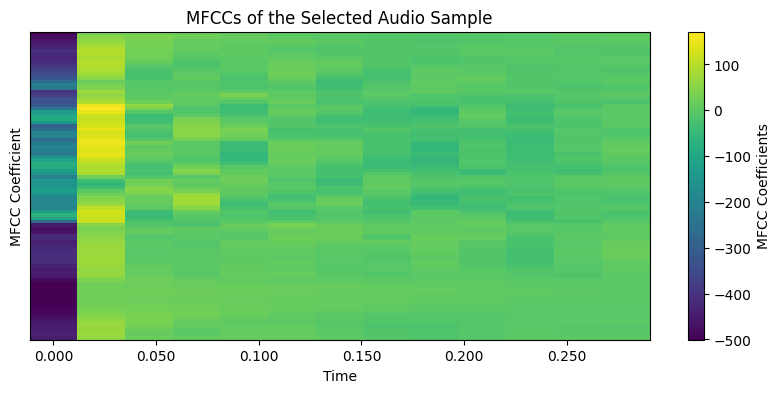

In [ ]:
# Path to one of the .npy files with MFCC features (replace this with a real .npy file from your output directory)
mfcc_file_path = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/train/LA_T_1000406.npy'  # Replace with an actual file path

# Load the MFCC features
mfcc_features = np.load(mfcc_file_path)

# Plot the MFCC features
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc_features.T, x_axis='time', cmap='viridis')
plt.colorbar(label='MFCC Coefficients')
plt.title("MFCCs of the Selected Audio Sample")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficient")
plt.show()


In [ ]:


# Path to the specific file you want to analyze
file_path = '/content/drive/My Drive/MENG/Deep Learning/Project/ASVspoof2019_NewSplit/train/LA_T_1000406.flac'  # Replace 'sample.flac' with the actual file name

# Function to extract MFCC features for the specified file
def extract_mfcc(file_path, sr=16000, n_mfcc=13):
    try:
        # Load the audio file and extract MFCC features
        signal, _ = librosa.load(file_path, sr=sr)
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)

        # Print the MFCC features to investigate
        print(f"MFCC features for {file_path}:")
        print(mfcc)

        # Return the MFCC for further analysis if needed
        return mfcc
    except Exception as e:
        print(f"Error extracting MFCC for {file_path}: {e}")
        return None

# Run MFCC extraction for the specified file
mfcc_features = extract_mfcc(file_path)


MFCC features for /content/drive/My Drive/MENG/Deep Learning/Project/ASVspoof2019_NewSplit/train/LA_T_1000406.flac:
[[-4.5068988e+02 -4.3824133e+02 -4.4483670e+02 ... -4.6264169e+02
  -4.7730191e+02 -4.9366968e+02]
 [ 6.2343189e+01  6.9328613e+01  6.4992584e+01 ...  6.1592125e+01
   5.0055935e+01  2.9972265e+01]
 [ 1.7929333e+01  1.2520369e+01  1.2622519e+01 ...  3.3038464e+01
   3.8138855e+01  2.5407709e+01]
 ...
 [ 1.5548412e+00  1.6150043e+00 -3.0374708e+00 ... -4.3394070e+00
  -4.6256933e+00 -3.7464681e+00]
 [-1.4246688e+00 -2.3486779e+00 -6.6953802e+00 ...  7.2207385e-01
   2.2111230e-02 -1.2637068e+00]
 [-1.2863915e+00 -2.6935186e+00 -6.5816746e+00 ...  3.1903205e+00
   3.6039076e+00  1.3467183e+00]]


In [ ]:
import numpy as np
import librosa

# Path to the specific file you want to analyze
file_path = '/content/drive/My Drive/MENG/Deep Learning/Project/ASVspoof2019_NewSplit/train/LA_T_1000406.flac'  # Replace 'sample.flac' with the actual file name

# Function to extract MFCC features for the specified file
def extract_mfcc(file_path, sr=16000, n_mfcc=13):
    try:
        # Load the audio file and extract MFCC features
        signal, _ = librosa.load(file_path, sr=sr)
        mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)

        # Set printing options for better readability
        np.set_printoptions(suppress=True, precision=2, linewidth=120)

        # Print the MFCC features to investigate
        print(f"MFCC features for {file_path} (shape: {mfcc.shape}):")
        print(mfcc)

        # Reset printing options if necessary
        np.set_printoptions(suppress=False)  # Optional: Reset to default if needed

        # Return the MFCC for further analysis if needed
        return mfcc
    except Exception as e:
        print(f"Error extracting MFCC for {file_path}: {e}")
        return None

# Run MFCC extraction for the specified file
mfcc_features = extract_mfcc(file_path)


MFCC features for /content/drive/My Drive/MENG/Deep Learning/Project/ASVspoof2019_NewSplit/train/LA_T_1000406.flac (shape: (13, 90)):
[[-450.69 -438.24 -444.84 ... -462.64 -477.3  -493.67]
 [  62.34   69.33   64.99 ...   61.59   50.06   29.97]
 [  17.93   12.52   12.62 ...   33.04   38.14   25.41]
 ...
 [   1.55    1.62   -3.04 ...   -4.34   -4.63   -3.75]
 [  -1.42   -2.35   -6.7  ...    0.72    0.02   -1.26]
 [  -1.29   -2.69   -6.58 ...    3.19    3.6     1.35]]


In [ ]:
import numpy as np

# Path to the .npy file you want to load
file_path = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/train/LA_T_1000648.npy'

# Load the .npy file
data = np.load(file_path)

# Print the shape and contents of the loaded array
print(f"Shape of data for MFCC: {data.shape}")
print("Contents of the file:")
print(data)


Shape of data for MFCC: (13, 61)
Contents of the file:
[[-5.15333130e+02 -4.18131165e+02 -2.38267273e+02 -1.75813919e+02
  -1.77791763e+02 -1.96437180e+02 -1.41670609e+02 -1.29074127e+02
  -1.59579178e+02 -2.05729813e+02 -1.29084473e+02 -1.09487679e+02
  -1.77208832e+02 -2.17358231e+02 -1.25525887e+02 -1.05413788e+02
  -1.07178314e+02 -1.09340645e+02 -1.29732132e+02 -1.48275375e+02
  -1.63342499e+02 -1.71683975e+02 -1.81971252e+02 -1.73910889e+02
  -2.06715179e+02 -2.79792358e+02 -2.23078110e+02 -1.63179047e+02
  -1.38174362e+02 -1.54439362e+02 -1.76453247e+02 -2.43314392e+02
  -3.05518555e+02 -2.91781982e+02 -1.76437180e+02 -1.53012314e+02
  -2.10567841e+02 -2.84156006e+02 -2.49738815e+02 -2.47092041e+02
  -1.91626709e+02 -9.99697571e+01 -1.07930283e+02 -1.83789642e+02
  -3.12476624e+02 -4.90582855e+02 -4.27205658e+02 -2.82127045e+02
  -1.57831314e+02 -1.43415268e+02 -1.84800186e+02 -2.03376404e+02
  -2.89402618e+02 -4.54796570e+02 -4.67993164e+02 -3.94900299e+02
  -3.10398773e+02 -3.

In [ ]:
from scipy.io import loadmat

# Path to the .mat file in your Colab working directory
file_path = 'LA_E_9994562_cqcc.mat'  # Replace with your actual file name

# Load the .mat file
data = loadmat(file_path)

# Inspect the loaded data
print("Keys in the .mat file:", data.keys())

# Access a specific variable (if you know its name)
variable_name = 'cqcc_features'  # Replace with actual variable name from .mat file
if variable_name in data:
    variable_data = data[variable_name]
    print(f"Data for '{variable_name}':")
    print(variable_data.shape)
    print(variable_data)


Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'cqcc_features'])
Data for 'cqcc_features':
(60, 304)
[[-1.93715417e+03 -1.93027039e+03 -1.91191267e+03 ... -2.01669451e+03
  -1.99531743e+03 -1.96200578e+03]
 [ 1.33401694e+02  1.53557736e+02  1.76203292e+02 ...  1.27736193e+02
   1.25223099e+02  1.26771144e+02]
 [ 8.96212268e+01  8.78161600e+01  8.95416060e+01 ...  1.01584421e+02
   1.05936551e+02  9.53894873e+01]
 ...
 [ 3.17775213e-01  2.16688478e-01  3.75028775e-02 ...  1.07704691e-01
   4.54718059e-01  6.39449050e-01]
 [-1.65119586e-01 -2.48503387e-01 -3.90235883e-01 ...  7.69593725e-01
   5.69704383e-01  1.66263197e-01]
 [-2.01894917e-01 -3.77923176e-01 -6.81477313e-01 ... -7.19462875e-01
  -7.03552852e-01 -3.04080878e-01]]


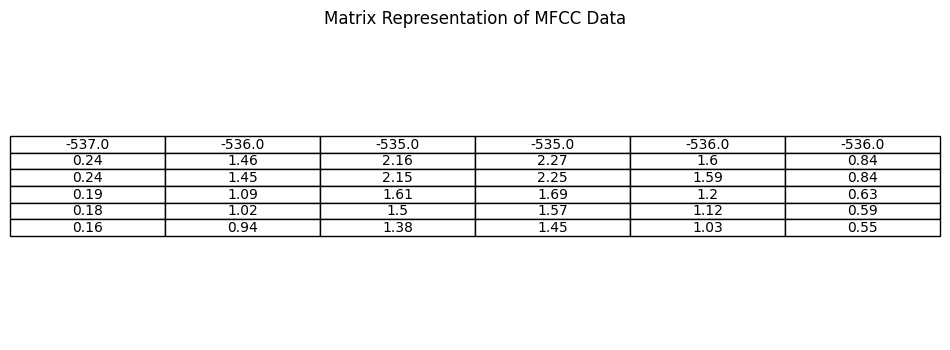

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data representing MFCC matrix
mfcc_data = np.array([
    [-5.37e+02, -5.36e+02, -5.35e+02, -5.35e+02, -5.36e+02, -5.36e+02],
    [2.45e-01, 1.46e+00, 2.16e+00, 2.27e+00, 1.60e+00, 8.42e-01],
    [2.43e-01, 1.45e+00, 2.15e+00, 2.25e+00, 1.59e+00, 8.35e-01],
    [1.88e-01, 1.09e+00, 1.61e+00, 1.69e+00, 1.20e+00, 6.34e-01],
    [1.77e-01, 1.02e+00, 1.50e+00, 1.57e+00, 1.12e+00, 5.93e-01],
    [1.65e-01, 9.37e-01, 1.38e+00, 1.45e+00, 1.03e+00, 5.48e-01]
])

# Plot the matrix representation without heatmap
plt.figure(figsize=(12, 4))
plt.table(cellText=mfcc_data.round(2), loc='center', cellLoc='center')
plt.axis('off')
plt.title('Matrix Representation of MFCC Data')
plt.show()



#clearn cqcc

In [ ]:
import os

# Replace with the paths to your dataset directories
train_dir = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_CQCC_Features/train/'
val_dir = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_CQCC_Features/val/'
test_dir = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_CQCC_Features/test/'

def count_mat_files(directory):
    return len([file for file in os.listdir(directory) if file.endswith('.mat')])

# Count the files in each dataset split
train_count = count_mat_files(train_dir)
val_count = count_mat_files(val_dir)
test_count = count_mat_files(test_dir)

# Print the results
print(f"Number of .mat files in the train set: {train_count}")
print(f"Number of .mat files in the validation set: {val_count}")
print(f"Number of .mat files in the test set: {test_count}")


Number of .mat files in the train set: 7027
Number of .mat files in the validation set: 1505
Number of .mat files in the test set: 1507


In [ ]:
import os
import scipy.io as sio

# Define input file paths
file_path_train = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_CQCC_Features/train'
file_path_val = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_CQCC_Features/val'
file_path_test = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_CQCC_Features/test'

# Define output file paths
output_path_train = '/content/drive/My Drive/MENG/Deep Learning/Project/CQCC_Features/train'
output_path_val = '/content/drive/My Drive/MENG/Deep Learning/Project/CQCC_Features/val'
output_path_test = '/content/drive/My Drive/MENG/Deep Learning/Project/CQCC_Features/test'

# Create output directories if they don't exist
os.makedirs(output_path_train, exist_ok=True)
os.makedirs(output_path_val, exist_ok=True)
os.makedirs(output_path_test, exist_ok=True)

# Function to process files in a given directory and save to a new location
def process_mat_files(input_dir, output_dir):
    for filename in os.listdir(input_dir):
        if filename.endswith('.mat'):
            file_path = os.path.join(input_dir, filename)
            try:
                # Load the .mat file
                mat_data = sio.loadmat(file_path)

                # Check if 'cqcc_features' exists in the file
                if 'cqcc_features' in mat_data:
                    cqcc_features = mat_data['cqcc_features']
                    new_data = {'cqcc_features': cqcc_features}

                    # Save the new .mat file in the output directory
                    output_file_path = os.path.join(output_dir, filename)
                    sio.savemat(output_file_path, new_data)
                    print(f"Processed and saved: {output_file_path}")
                else:
                    print(f"'cqcc_features' not found in {file_path}. Skipping.")
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

# Process the train, val, and test directories
process_mat_files(file_path_train, output_path_train)
process_mat_files(file_path_val, output_path_val)
process_mat_files(file_path_test, output_path_test)

print("Processing complete. New .mat files with only 'cqcc_features' have been created.")


In [ ]:
import os

# Replace with the paths to your dataset directories
train_dir = '/content/drive/My Drive/MENG/Deep Learning/Project/CQCC_Features/train/'
val_dir = '/content/drive/My Drive/MENG/Deep Learning/Project/CQCC_Features/val/'
test_dir = '/content/drive/My Drive/MENG/Deep Learning/Project/CQCC_Features/test/'

def count_mat_files(directory):
    return len([file for file in os.listdir(directory) if file.endswith('.mat')])

# Count the files in each dataset split
train_count = count_mat_files(train_dir)
val_count = count_mat_files(val_dir)
test_count = count_mat_files(test_dir)

# Print the results
print(f"Number of .mat files in the train set: {train_count}")
print(f"Number of .mat files in the validation set: {val_count}")
print(f"Number of .mat files in the test set: {test_count}")

Number of .mat files in the train set: 7027
Number of .mat files in the validation set: 1505
Number of .mat files in the test set: 1507


In [ ]:
# Reading one of the newly created .mat files to check its content
import scipy.io as sio

# Example path to a processed .mat file (adjust as necessary)
example_file_path = '/content/drive/My Drive/MENG/Deep Learning/Project/CQCC_Features/train/LA_T_9975312_cqcc.mat'  # Replace 'example.mat' with an actual filename

try:
    new_mat_data = sio.loadmat(example_file_path)
    # Display the keys and data in the loaded .mat file
    print("Keys in the .mat file:", new_mat_data.keys())
    print("Data for 'cqcc_features':", new_mat_data['cqcc_features'])
except FileNotFoundError:
    print(f"File not found: {example_file_path}")
except Exception as e:
    print(f"Error reading the file: {e}")


Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'cqcc_features'])
Data for 'cqcc_features': b'MATLAB 5.0 MAT-file Platform: posix, Created on: Mon Nov  4 02:08:20 2024'


In [ ]:
import scipy.io as sio
# Load and check one of the processed files to confirm the content
processed_file_path = '/content/drive/My Drive/MENG/Deep Learning/Project/CQCC_Features/train/LA_T_1000406_cqcc.mat'  # Replace 'example.mat' with an actual file

new_mat_data = sio.loadmat(processed_file_path)
print("Keys in the processed .mat file:", new_mat_data.keys())


Keys in the processed .mat file: dict_keys(['__header__', '__version__', '__globals__', 'cqcc_features'])


In [ ]:
import os

# Specify the folder path
mfcc_path = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/train/'

# Count the number of files in the folder
num_files = len([f for f in os.listdir(mfcc_path) if os.path.isfile(os.path.join(mfcc_path, f))])

print(f"There are {num_files} files in the folder.")


There are 7027 files in the folder.


In [ ]:
import os

# Specify the folder path
mfcc_path = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/test/'

# Count the number of files in the folder
num_files = len([f for f in os.listdir(mfcc_path) if os.path.isfile(os.path.join(mfcc_path, f))])

print(f"There are {num_files} files in the folder.")


There are 1507 files in the folder.


In [ ]:
import os

# Specify the folder path
mfcc_path = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/val/'

# Count the number of files in the folder
num_files = len([f for f in os.listdir(mfcc_path) if os.path.isfile(os.path.join(mfcc_path, f))])

print(f"There are {num_files} files in the folder.")


There are 1505 files in the folder.


In [ ]:
import os
from collections import Counter

# Specify the folder path
mfcc_path = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/train/'

# Get all filenames in the specified folder
file_names = [f for f in os.listdir(mfcc_path) if os.path.isfile(os.path.join(mfcc_path, f))]

# Count occurrences of each filename
file_counts = Counter(file_names)

# Find duplicates (files with more than one occurrence)
duplicates = [file for file, count in file_counts.items() if count > 1]

if duplicates:
    print(f"Duplicate filenames found: {duplicates}")
else:
    print("No duplicate filenames found.")


No duplicate filenames found.


In [ ]:
import os

mfcc_path = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/train/'
all_files = os.listdir(mfcc_path)

# Print the first few files to see if there are any hidden ones
print(all_files[:10])  # Adjust as needed to see the list of files
print(f"Total number of items (including hidden): {len(all_files)}")


['LA_T_1088656.npy', 'LA_T_1087556.npy', 'LA_T_1081570.npy', 'LA_T_1087286.npy', 'LA_T_1081824.npy', 'LA_T_1081004.npy', 'LA_T_1067682.npy', 'LA_T_1083769.npy', 'LA_T_1084255.npy', 'LA_T_1069388.npy']
Total number of items (including hidden): 7027


In [ ]:
import os

mfcc_path = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/train/'

# List all items and check for symlinks or unusual files
unusual_files = [f for f in os.listdir(mfcc_path) if not os.path.isfile(os.path.join(mfcc_path, f))]

print(f"Unusual items (symlinks or directories): {unusual_files}")


Unusual items (symlinks or directories): []


In [ ]:
import numpy as np

# Define the path to your .npy file
file_path = '/content/drive/My Drive/MENG/Deep Learning/Project/Fixed_length_frame_processed/Processed_train/processed_mfcc_train.npy'  # Replace with your actual file path

# Load the .npy file
data = np.load(file_path)

# Check if there are at least 5 samples and read the first 5 samples
first_five_samples = data[:5] if data.shape[0] >= 5 else data

# Display the first 5 samples
print("First 5 samples:")
print(first_five_samples)


First 5 samples:
[[[-5.75331238e+02 -5.68193542e+02 -5.65143677e+02 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 3.75575790e+01  4.69475403e+01  5.09284210e+01 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 2.88543510e+01  3.62918777e+01  3.93660049e+01 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  ...
  [-5.89553642e+00 -8.49519920e+00 -9.21837234e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [-3.84527111e+00 -6.31011915e+00 -7.68478394e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [-2.50435328e+00 -5.12443972e+00 -7.40222740e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]]

 [[-5.48645081e+02 -3.76908264e+02 -2.47773834e+02 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 3.90908966e+01  1.23739876e+02  1.29849762e+02 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 2.32744026e+01 -7.78007793e+00 -5.91613312e+01 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  ...
  [ 5.

In [ ]:
import os

# Define paths
base_path = '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features'
train_folder = os.path.join(base_path, 'train')
val_folder = os.path.join(base_path, 'val')
test_folder = os.path.join(base_path, 'test')

# Define text file paths
train_txt_path = '/content/drive/My Drive/MENG/Deep Learning/Project/Fixed_length_frame_processed/ASVspoof2019.LA.cm.train.trn.txt'
val_txt_path = '/content/drive/My Drive/MENG/Deep Learning/Project/Fixed_length_frame_processed/ASVspoof2019.LA.cm.dev.trl.txt'
test_txt_path = '/content/drive/My Drive/MENG/Deep Learning/Project/Fixed_length_frame_processed/ASVspoof2019.LA.cm.eval.trl.txt'

# Define output paths for new txt files
output_train_txt = '/content/drive/My Drive/MENG/Deep Learning/Project/filtered_train_files.txt'
output_val_txt = '/content/drive/My Drive/MENG/Deep Learning/Project/filtered_val_files.txt'
output_test_txt = '/content/drive/My Drive/MENG/Deep Learning/Project/filtered_test_files.txt'

# Function to extract and keep entire rows if the filename matches a file in the folder
def filter_rows(txt_path, folder_path, output_path, expected_count):
    # Load the list of files in the folder
    folder_files = {os.path.splitext(f)[0] for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))}

    # Initialize a list to store matched rows
    matched_rows = []

    # Read through the input text file
    with open(txt_path, 'r') as file:
        lines = file.readlines()
        for line in lines:
            # Extract the second column (file name)
            filename = line.split()[1]

            # Check if the filename exists in the folder
            if filename in folder_files:
                matched_rows.append(line.strip())  # Keep the entire row

    # Check if the count of matched rows meets the expected count
    if len(matched_rows) == expected_count:
        print(f"All {expected_count} files matched in '{folder_path}'.")
    else:
        print(f"WARNING: Expected {expected_count} files, but found {len(matched_rows)} matches in '{folder_path}'.")

    # Save matched rows to a new text file
    with open(output_path, 'w') as out_file:
        for row in matched_rows:
            out_file.write(f"{row}\n")
    print(f"Matched rows saved to '{output_path}'.")

# Process train, val, and test sets
filter_rows(train_txt_path, train_folder, output_train_txt, 7027)
filter_rows(val_txt_path, val_folder, output_val_txt, 1505)
filter_rows(test_txt_path, test_folder, output_test_txt, 1507)



All 7027 files matched in '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/train'.
Matched rows saved to '/content/drive/My Drive/MENG/Deep Learning/Project/filtered_train_files.txt'.
All 1505 files matched in '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/val'.
Matched rows saved to '/content/drive/My Drive/MENG/Deep Learning/Project/filtered_val_files.txt'.
All 1507 files matched in '/content/drive/My Drive/MENG/Deep Learning/Project/ASV_MFCC_Features/test'.
Matched rows saved to '/content/drive/My Drive/MENG/Deep Learning/Project/filtered_test_files.txt'.


In [ ]:
# Define paths to the filtered text files
output_train_txt = '/content/drive/My Drive/MENG/Deep Learning/Project/train_labels.txt'
output_val_txt = '/content/drive/My Drive/MENG/Deep Learning/Project/val_labels.txt'
output_test_txt = '/content/drive/My Drive/MENG/Deep Learning/Project/test_labels.txt'

# Function to count lines in a text file
def count_files_in_txt(file_path):
    with open(file_path, 'r') as file:
        count = sum(1 for line in file)
    return count

# Count the number of files in each text file
train_count = count_files_in_txt(output_train_txt)
val_count = count_files_in_txt(output_val_txt)
test_count = count_files_in_txt(output_test_txt)

# Print the results
print(f"Number of files in 'filtered_train_files.txt': {train_count}")
print(f"Number of files in 'filtered_val_files.txt': {val_count}")
print(f"Number of files in 'filtered_test_files.txt': {test_count}")


Number of files in 'filtered_train_files.txt': 7027
Number of files in 'filtered_val_files.txt': 1505
Number of files in 'filtered_test_files.txt': 1507


In [ ]:
import numpy as np

# Specify the path to your .npz file
file_path = '/content/drive/My Drive/MENG/Deep Learning/Project/Fixed_length_frame_processed/Processed_train/processed_cqcc_train.npz'

# Load the .npz file
data = np.load(file_path)

# List all keys (array names) in the .npz file
print("Keys in the .npz file:", data.files)

# Access and print each array
for key in data.files:
    print(f"Array '{key}':")
    print(data[key])  # Display the data for each array
    print(f"Shape of '{key}': {data[key].shape}")
    print()  # Add a newline for readability


Keys in the .npz file: ['data', 'file_names']
Array 'data':
[]
Shape of 'data': (0,)

Array 'file_names':
[]
Shape of 'file_names': (0,)



In [ ]:
import numpy as np

# Path to your .npz file
npz_path = '/content/drive/My Drive/MENG/Deep Learning/Project/Fixed_length_frame_processed/Processed_train/processed_cqcc_train.npz'

# Load the .npz file and list all keys
data = np.load(npz_path)
print("Keys in the .npz file:", data.files)

# Check if a specific key exists
sample_id = 'LA_T_8695002'
if sample_id in data.files:
    print(f"Sample ID {sample_id} exists in the file.")
else:
    print(f"Sample ID {sample_id} NOT found in the file.")


Keys in the .npz file: ['data', 'file_names']
Sample ID LA_T_8695002 NOT found in the file.


In [ ]:
import numpy as np

# Define file paths
npz_path = '/content/drive/My Drive/MENG/Deep Learning/Project/Fixed_length_frame_processed/Processed_train/processed_mfcc_train.npz'
labels_path = '/content/drive/My Drive/MENG/Deep Learning/Project/Fixed_length_frame_processed/train_labels.txt'

# Step 1: Load the sample names from the .npz file and remove the .npy extension
with np.load(npz_path) as npz_file:
    npz_sample_names = set(f.replace('.npy', '') for f in npz_file['file_names'])  # Remove .npy extension

# Step 2: Load the sample names from the second column of the labels file
label_sample_names = set()
with open(labels_path, 'r') as file:
    for line in file:
        sample_name = line.split()[1]  # Extract the second column
        label_sample_names.add(sample_name)

# Step 3: Compare the two sets
missing_in_labels = npz_sample_names - label_sample_names
missing_in_npz = label_sample_names - npz_sample_names

# Print results
if not missing_in_labels and not missing_in_npz:
    print("All sample names in processed_mfcc_train.npz match with those in train_labels.txt.")
else:
    if missing_in_labels:
        print("Sample names in .npz file but missing in train_labels.txt:", missing_in_labels)
    if missing_in_npz:
        print("Sample names in train_labels.txt but missing in .npz file:", missing_in_npz)


All sample names in processed_mfcc_train.npz match with those in train_labels.txt.
